# Cross-Regional Housing Price Prediction & Generalization Study
## Phase 6 — Error Analysis

Overall RMSE tells us HOW WRONG the model is on average.
But it doesn't tell us WHERE it goes wrong and WHY.

This phase investigates:
1. Does the model struggle more with expensive houses?
2. Are some neighborhoods harder to predict than others?
3. Is there a pattern in the residuals (errors)?

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

with open('/content/drive/MyDrive/Housing_Project/utils.py', 'r') as f:
    exec(f.read())

ames, kc = load_raw()
print(ames.shape, kc.shape)

X_train = load_processed('X_train.csv')
X_test = load_processed('X_test.csv')
y_train = load_processed('y_train.csv').squeeze()
y_test = load_processed('y_test.csv').squeeze()

with open('/content/drive/MyDrive/Housing_Project/data/models/best_xgb.pkl', 'rb') as f:
    best_xgb = pickle.load(f)

y_pred = best_xgb.predict(X_test)

print(f"Test set: {len(y_test)} houses")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2930, 82) (21613, 21)
Test set: 586 houses


### 6.1 Investigation 1 — Error by Price Tier

First I need to split houses into 3 groups based on actual price.
The goal is to check if model error is different for cheap vs expensive houses.

Hypothesis H2 says: luxury houses will have higher error because
they are rare in training data — model has fewer examples to learn from.

Let's first check how many houses fall in each price range.

In [ ]:
print(y_test.describe())
print(f"\nBelow $150k: {(y_test < 150000).sum()}")
print(f"$150k-$300k: {((y_test >= 150000) & (y_test < 300000)).sum()}")
print(f"Above $300k: {(y_test >= 300000).sum()}")

count       586.000000
mean     189651.469283
std       89617.259169
min       44000.000000
25%      130000.000000
50%      165000.000000
75%      228375.000000
max      625000.000000
Name: SalePrice, dtype: float64

Below $150k: 242
$150k-$300k: 279
Above $300k: 65


Thresholds decided:
- Low: below $150k (242 houses)
- Mid: $150k - $300k (279 houses)  
- Luxury: above $300k (63 houses — only 11% of test set!)

Creating a results dataframe with actual price, predicted price,
residual (actual - predicted) and price tier for each house.

In [ ]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'residual': y_test - y_pred,
    'price_tier': pd.cut(y_test, bins=[0, 150000, 300000, float('inf')],
                         labels=['Low', 'Mid', 'Luxury'])
})

print(results_df.head())
print(results_df['price_tier'].value_counts())

   actual      predicted      residual price_tier
0  161000  175654.625000 -14654.625000        Mid
1  116000  103656.335938  12343.664062        Low
2  196500  185764.750000  10735.250000        Mid
3  123600  120616.445312   2983.554688        Low
4  126000  110600.093750  15399.906250        Low
price_tier
Mid       279
Low       244
Luxury     63
Name: count, dtype: int64


Now calculating RMSE, MAE and average residual for each tier separately.
Mean residual tells us if the model systematically over or underpredicts.
Positive mean residual = model underpredicts (actual > predicted).

In [ ]:
tier_analysis = results_df.groupby('price_tier', observed=True).apply(
    lambda x: pd.Series({
        'count': len(x),
        'RMSE': root_mean_squared_error(x['actual'], x['predicted']),
        'MAE': mean_absolute_error(x['actual'], x['predicted']),
        'mean_actual': x['actual'].mean(),
        'mean_residual': x['residual'].mean()
    })
).round(0)

print(tier_analysis)

            count     RMSE      MAE  mean_actual  mean_residual
price_tier                                                     
Low         244.0  12356.0   9030.0     119528.0        -1524.0
Mid         279.0  17744.0  12200.0     206676.0        -1346.0
Luxury       63.0  50604.0  36934.0     385845.0        20090.0


/tmp/ipykernel_598/2984051519.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tier_analysis = results_df.groupby('price_tier', observed=True).apply(


Visualizing RMSE by price tier — the bar chart will make the difference obvious.

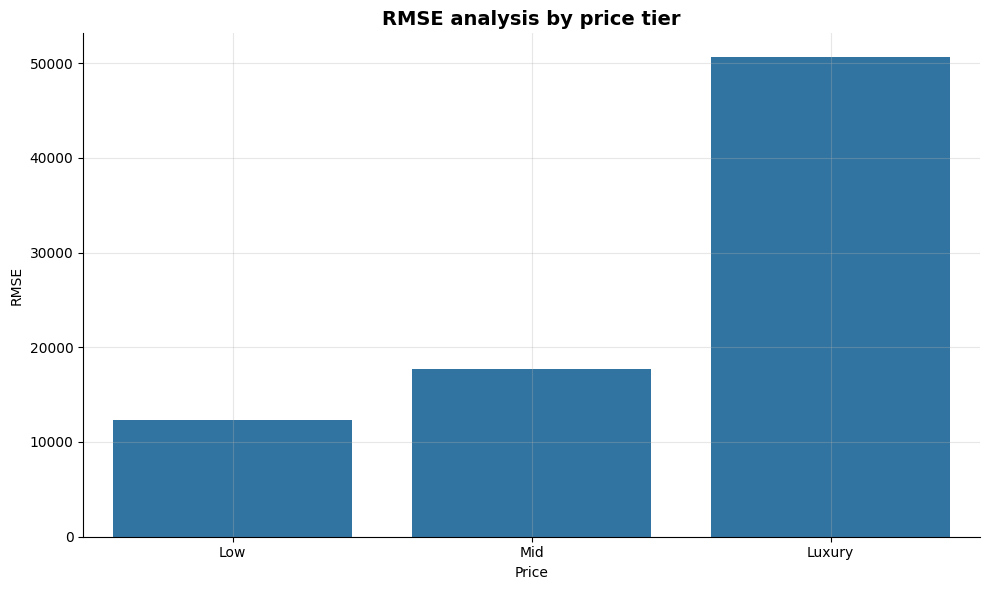

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=tier_analysis.index, y=tier_analysis['RMSE'])
plt.title('RMSE analysis by price tier', fontsize=14, fontweight='bold')
plt.xlabel('Price')
plt.ylabel('RMSE');
plt.grid(alpha=0.3)
plt.tight_layout();
sns.despine();
plt.show()


### Finding 1 — H2 CONFIRMED

Low tier RMSE:    12,356
Mid tier RMSE:    17,744
Luxury tier RMSE: 50,604 — 4x worse than low tier!

The model is catastrophically wrong on luxury houses.
Also: luxury mean residual = +20,090 meaning the model
UNDERPREDICTS luxury houses by 20k on average.
This makes sense — only 63 luxury houses in test set,
model didn't see enough examples to learn luxury pricing patterns.

### 6.2 Investigation 2 — Error by Neighborhood

Now checking if some neighborhoods are harder to predict than others.
Original hypothesis: rare neighborhoods → higher error.
Let's see if that's actually true.

In [12]:
neighborhood_analysis = results_df.copy()
neighborhood_analysis['neighborhood'] = ames.loc[y_test.index, 'Neighborhood'].values

neigh_rmse = neighborhood_analysis.groupby('neighborhood').apply(
    lambda x: pd.Series({
        'count': len(x),
        'RMSE': root_mean_squared_error(x['actual'], x['predicted']),
        'mean_actual': x['actual'].mean()
    }), include_groups=False
).sort_values('RMSE', ascending=False)

print(neigh_rmse)

              count          RMSE    mean_actual
neighborhood                                    
OldTown        29.0  34733.691406  193501.310345
Blmngtn         8.0  30145.216797  176500.000000
Somerst        61.0  28438.185547  193121.278689
NridgHt        60.0  26125.595703  198603.800000
Sawyer         33.0  25292.105469  186961.666667
Edwards        23.0  23411.992188  197781.956522
NAmes          73.0  22874.464844  194543.506849
IDOTRR          9.0  21470.636719  222938.888889
SawyerW        39.0  19489.933594  207468.153846
Timber          8.0  18947.169922  285947.875000
NPkVill        14.0  18704.000000  160656.428571
StoneBr        14.0  18406.195312  165920.214286
Mitchel        17.0  18285.900391  194505.882353
CollgCr        21.0  17924.753906  168039.619048
NWAmes         36.0  17650.390625  174000.222222
BrDale          9.0  17295.599609  213086.666667
Gilbert        56.0  15191.734375  165887.250000
MeadowV         7.0  14932.270508  207910.000000
SWISU          11.0 

OldTown has highest RMSE (34,733) but 29 houses — not rare at all!

Checking if high price variance within neighborhood explains the error better.

In [13]:
neighborhood_analysis.groupby('neighborhood').apply(
    lambda x: pd.Series({
        'count': len(x),
        'RMSE': root_mean_squared_error(x['actual'], x['predicted']),
        'price_std': x['actual'].std()
    }), include_groups=False
).sort_values('RMSE', ascending=False).head(10)

,count,RMSE,price_std
neighborhood,,,
OldTown,29.0,34733.691406,115873.433185
Blmngtn,8.0,30145.216797,62598.493820
Somerst,61.0,28438.185547,100152.634327
NridgHt,60.0,26125.595703,92622.480308
Sawyer,33.0,25292.105469,69522.480649
Edwards,23.0,23411.992188,62093.341298
NAmes,73.0,22874.464844,96300.433539
IDOTRR,9.0,21470.636719,101887.756188
SawyerW,39.0,19489.933594,91983.025292


### Finding 2 — H4 REVISED

Original H4: "Rare neighborhoods will have high error"
Actual finding: HIGH PRICE VARIANCE neighborhoods have high error.

OldTown: RMSE = 34,733, price_std = 115,873 (highest variance!)
OldTown has mix of very old cheap houses AND renovated expensive ones.
Model sees "OldTown" and predicts average — but actual prices are spread wide.

Lesson: it's not about how COMMON a neighborhood is,
it's about how CONSISTENT the prices are within it.

### 6.3 Investigation 3 — Residual Pattern Analysis

Plotting residuals against actual price and predicted price.
If we see a pattern → model is systematically missing something.
Random scatter around zero = model is unbiased.

residual = actual - predicted
Positive residual = model underpredicted (actual > predicted)
Negative residual = model overpredicted (predicted > actual)

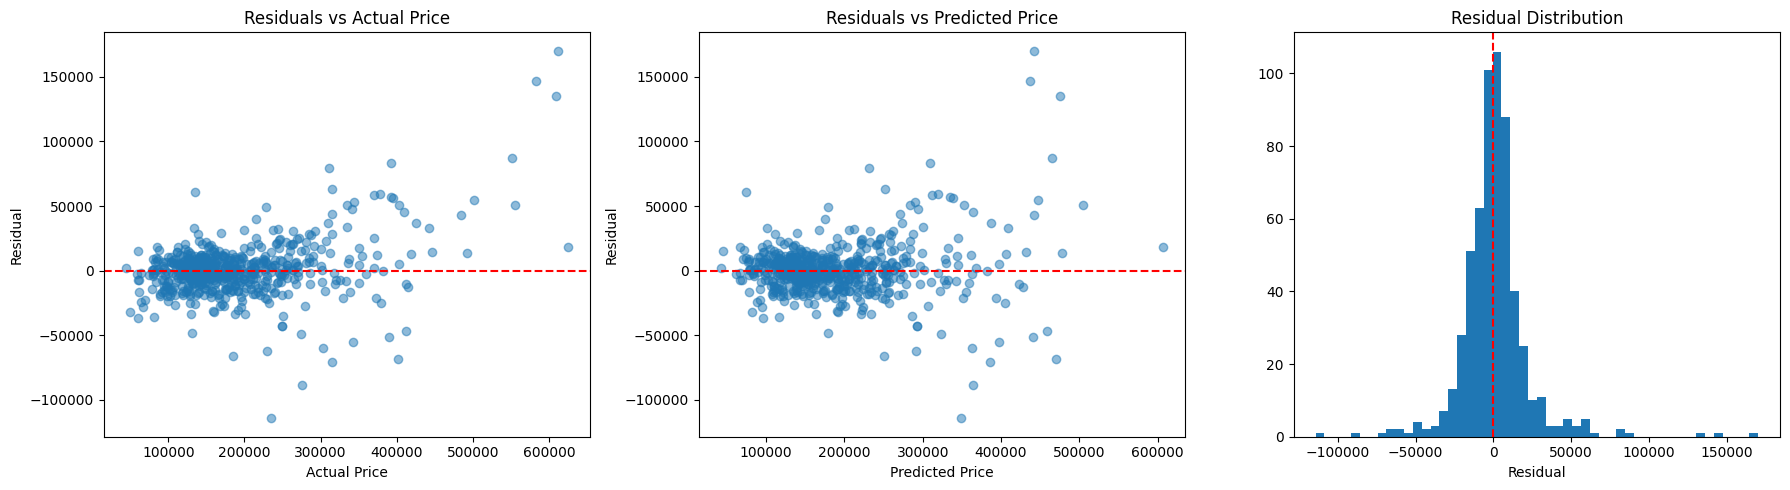

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(results_df['actual'], results_df['residual'], alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Actual Price')

axes[1].scatter(results_df['predicted'], results_df['residual'], alpha=0.5)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted Price')

axes[2].hist(results_df['residual'], bins=50)
axes[2].axvline(x=0, color='red', linestyle='--')
axes[2].set_xlabel('Residual')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

### Finding 3 — Heteroscedasticity

The residual plots show a clear FAN SHAPE — errors spread out as price increases.
This is called heteroscedasticity (fancy word for "error is not constant").

For low/mid prices: residuals are small and random around zero
For high prices: residuals are large and mostly positive (underprediction)

The residual distribution is roughly symmetric — no massive systematic bias
for typical houses. The luxury underprediction creates a slight right tail.

### Overall Phase 6 Conclusion

The model performs well for typical houses (100k-200k range)
but struggles significantly with luxury houses (>300k).
This is expected given how few luxury houses exist in our training data.
To improve luxury predictions we would need:
- More luxury house examples in training data
- Or a separate model trained specifically on luxury segment